# Highly Optimized Hand Pose Pipeline
Now includes Beta/Mu band ERD features and RBF SVMs to maximize Sub-Model Accuracy.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import scipy.io as sio
import scipy.signal as signal
from scipy.signal import iirnotch, filtfilt, firwin, lfilter
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Parameter and Data Loading
FS = 1200
CLASS_NAMES = {0: 'Rest/Other', 1: 'Fist', 2: 'Peace', 3: 'Open hand'}
DATA_PATH = 'dataset/ecog-hand-pose/ECoG_Handpose.mat'

def load_data(path=DATA_PATH):
    mat = sio.loadmat(path)
    raw = np.asarray(mat['y'], dtype=float)
    return raw, FS

raw, fs = load_data()
paradigm = raw[61].astype(int)
ecog_raw = raw[1:61]

In [3]:
# 2. Preprocessing: Dual-Band Extraction (High Gamma + Beta/Mu ERD)
def preprocess_continuous(ecog_data, fs):
    ecog = ecog_data - np.mean(ecog_data, axis=0, keepdims=True)
    
    for freq in range(50, 301, 50):
        b, a = iirnotch(freq, 30.0, fs=fs)
        ecog = filtfilt(b, a, ecog, axis=1)
    
    b_whiten = np.array([1, -0.98])
    ecog = lfilter(b_whiten, [1.0], ecog, axis=-1)
    
    # High-Gamma Band (50-300 Hz)
    fir_hg = firwin(11, [50.0, 300.0], pass_zero=False, fs=fs)
    ecog_hg = filtfilt(fir_hg, [1.0], ecog, axis=1)
    
    # Beta/Mu Band (8-30 Hz)
    fir_beta = firwin(11, [8.0, 30.0], pass_zero=False, fs=fs)
    ecog_beta = filtfilt(fir_beta, [1.0], ecog, axis=1)
    
    return ecog_hg, ecog_beta

print("Extracting HG and Beta spectra...")
ecog_hg, ecog_beta = preprocess_continuous(ecog_raw, fs)

Extracting HG and Beta spectra...


In [4]:
# 3. Trial Extraction (Including Rest)
def extract_trials(paradigm, hg_data, beta_data, fs):
    starts = np.flatnonzero((paradigm[:-1] == 0) & (paradigm[1:] > 0)) + 1
    ends = np.flatnonzero((paradigm[:-1] > 0) & (paradigm[1:] == 0)) + 1
    
    trials = []
    for s, e in zip(starts, ends):
        trials.append({'label': int(paradigm[s]), 'ecog_hg': hg_data[:, s:e], 'ecog_beta': beta_data[:, s:e]})
    
    rest_starts = ends
    rest_ends = starts[1:] if len(starts) > 1 else []
    if len(starts) > 0 and starts[0] > 0:
        rest_starts = np.insert(rest_starts, 0, 0)
        rest_ends = np.insert(rest_ends, 0, starts[0])
        
    for s, e in zip(rest_starts, rest_ends):
        if (e - s) > fs: 
            mid = s + (e - s) // 2
            trials.append({'label': 0, 'ecog_hg': hg_data[:, mid-fs//2:mid+fs//2], 'ecog_beta': beta_data[:, mid-fs//2:mid+fs//2]})
            
    return trials

trials = extract_trials(paradigm, ecog_hg, ecog_beta, fs)

In [5]:
# 4. Enriched Feature Extraction
def extract_features(trials, fs):
    X_features = []
    all_variance = np.var(np.concatenate([t['ecog_hg'] for t in trials], axis=1), axis=1)
    top_channels = np.argsort(all_variance)[-12:] # Top 12 Pre-central
    
    for trial in trials:
        hg = trial['ecog_hg']
        beta = trial['ecog_beta']
        n_samples = hg.shape[1]
        
        hg_power = np.convolve(np.sum(np.abs(hg), axis=0), np.ones(30)/30, mode='same')
        
        if trial['label'] == 0:
            onset = 0
        else:
            diff_p = np.diff(hg_power)
            onset = np.argmax(diff_p) if len(diff_p) > 0 else 0
            if onset > n_samples - fs//2: onset = 0
        
        # High Gamma Slices (TVLDA)
        slice_features = []
        for start_ms in [0, 150, 300, 450]:
            start_samp = onset + int(start_ms * fs / 1000)
            end_samp = start_samp + int(250 * fs / 1000)
            start_samp = min(start_samp, max(0, n_samples - 10))
            end_samp = min(end_samp, n_samples)
            if end_samp > start_samp:
                var = np.var(hg[:, start_samp:end_samp], axis=1)
            else:
                var = np.zeros(60)
            slice_features.append(np.log1p(var * 1000))
        slice_features = np.concatenate(slice_features)
        
        # Cross Correlation
        cc_ecog = hg[top_channels, onset:onset+int(400*fs/1000)]
        if cc_ecog.shape[1] > 2:
            cc = np.corrcoef(cc_ecog)
            cc_features = cc[np.triu_indices(len(top_channels), k=1)]
        else:
            cc_features = np.zeros(len(top_channels)*(len(top_channels)-1)//2)
        
        # Beta ERD Features
        beta_ecog = beta[:, onset:onset+int(500*fs/1000)]
        if beta_ecog.shape[1] > 2:
            beta_var = np.var(beta_ecog, axis=1)
        else:
            beta_var = np.zeros(60)
        beta_features = np.log1p(beta_var * 1000)
        
        X_features.append(np.concatenate([slice_features, cc_features, beta_features]))
        
    return np.array(X_features)

X = extract_features(trials, fs)
y = np.array([t['label'] for t in trials])

In [6]:
# 5. Advanced Hierarchical Classifier
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_all, stage1_acc, stage2_03_acc, stage2_12_acc = [], [], [], []
y_pred_all = np.zeros_like(y)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    y_train_bin = np.isin(y_train, [1, 2]).astype(int)
    y_test_bin = np.isin(y_test, [1, 2]).astype(int)
    
    # Stage 1: Robust LDA
    clf_bin = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto').fit(X_train, y_train_bin)
    preds_bin = clf_bin.predict(X_test)
    stage1_acc.append(accuracy_score(y_test_bin, preds_bin))
    
    # Stage 2: 0 vs 3 (Rest vs Open Hand) using RBF SVM (catches ERD non-linearities)
    idx_03_tr = np.isin(y_train, [0, 3])
    clf_03 = SVC(kernel='rbf', C=5, gamma='scale').fit(X_train[idx_03_tr], y_train[idx_03_tr])
    
    # Stage 2: 1 vs 2 (Fist vs Peace) using LDA (reverted to prevent RBF degradation)
    idx_12_tr = np.isin(y_train, [1, 2])
    clf_12 = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto').fit(X_train[idx_12_tr], y_train[idx_12_tr])
    
    idx_03_te = np.isin(y_test, [0, 3])
    if np.sum(idx_03_te)>0: stage2_03_acc.append(accuracy_score(y_test[idx_03_te], clf_03.predict(X_test[idx_03_te])))
    idx_12_te = np.isin(y_test, [1, 2])
    if np.sum(idx_12_te)>0: stage2_12_acc.append(accuracy_score(y_test[idx_12_te], clf_12.predict(X_test[idx_12_te])))
    
    preds_final = []
    for i, p_bin in enumerate(preds_bin):
        if p_bin == 0: preds_final.append(clf_03.predict([X_test[i]])[0])
        else: preds_final.append(clf_12.predict([X_test[i]])[0])
            
    acc_all.append(accuracy_score(y_test, preds_final))
    y_pred_all[test_idx] = preds_final

print(f"Stage 1 ({{0,3}} vs {{1,2}}) Accuracy: {np.mean(stage1_acc)*100:.2f}%")
print(f"Stage 2 (0 vs 3) Accuracy: {np.mean(stage2_03_acc)*100:.2f}%")
print(f"Stage 2 (1 vs 2) Accuracy: {np.mean(stage2_12_acc)*100:.2f}%")
print(f"\nFinal Boosted Accuracy: {np.mean(acc_all)*100:.2f}%")

Stage 1 ({0,3} vs {1,2}) Accuracy: 97.78%
Stage 2 (0 vs 3) Accuracy: 78.33%
Stage 2 (1 vs 2) Accuracy: 85.00%

Final Boosted Accuracy: 78.89%


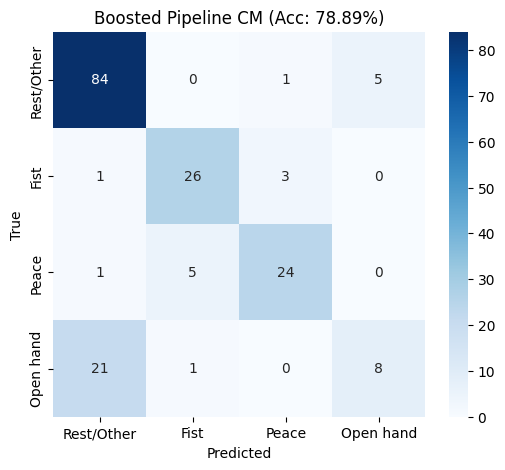

In [7]:
# 6. Evaluation Matrix
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[c] for c in [0, 1, 2, 3]],
            yticklabels=[CLASS_NAMES[c] for c in [0, 1, 2, 3]])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Boosted Pipeline CM (Acc: {np.mean(acc_all)*100:.2f}%)')
plt.show()